# Classificação de Gênero de Livros com Machine Learning

Este notebook apresenta a construção de um modelo de Machine Learning capaz de classificar o gênero de livros com base em seus títulos e sinopses.

O problema abordado é de **classificação supervisionada**, onde o objetivo é prever a categoria (gênero) a partir de dados textuais.

Serão utilizadas técnicas clássicas de Machine Learning com a biblioteca Scikit-Learn, incluindo:
- Pré-processamento de dados
- Vetorização de texto (TF-IDF)
- Modelagem com diferentes algoritmos
- Validação cruzada
- Otimização de hiperparâmetros
- Avaliação de desempenho
- Exportação do modelo final

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report

## Carregamento dos Dados

Os dados foram carregados a partir de um arquivo CSV contendo informações sobre livros.

In [12]:
url = "https://raw.githubusercontent.com/stephaniefay/s4-mvp/refs/heads/main/backend/Machine%20Learning/data.csv"
dataset = pd.read_csv(url)

dataset.head()

,Unnamed: 0,title,rating,name,num_ratings,num_reviews,num_followers,synopsis,genre
0,0,Sapiens: A Brief History of Humankind,4.39,Yuval Noah Harari,"8,06,229","46,149",30.5k,"100,000 years ago, at least six human species ...",history
1,1,"Guns, Germs, and Steel: The Fates of Human Soc...",4.04,Jared Diamond,"3,67,056","12,879","6,538","""Diamond has written a book of remarkable scop...",history
2,2,A People's History of the United States,4.07,Howard Zinn,"2,24,620","6,509","2,354","In the book, Zinn presented a different side o...",history
3,3,"The Devil in the White City: Murder, Magic, an...",3.99,Erik Larson,"6,13,157","36,644",64.2k,Author Erik Larson imbues the incredible event...,history
4,4,The Diary of a Young Girl,4.18,Anne Frank,"33,13,033","35,591","4,621",Discovered in the attic in which she spent the...,history


## Análise Inicial dos Dados

Nesta etapa, analisamos a estrutura da base de dados e verificamos possíveis valores ausentes.

In [13]:
dataset.info()
dataset.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1539 entries, 0 to 1538
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     1539 non-null   int64  
 1   title          1539 non-null   object 
 2   rating         1539 non-null   float64
 3   name           1539 non-null   object 
 4   num_ratings    1539 non-null   object 
 5   num_reviews    1539 non-null   object 
 6   num_followers  1539 non-null   object 
 7   synopsis       1539 non-null   object 
 8   genre          1539 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 108.3+ KB


,0
Unnamed: 0,0
title,0
rating,0
name,0
num_ratings,0
num_reviews,0
num_followers,0
synopsis,0
genre,0


## Pré-processamento dos Dados

Foi criada uma nova variável textual combinando o título e a sinopse dos livros, além de remover registros com valores ausentes.

In [15]:
dataset = dataset.dropna()

dataset['text'] = dataset['title'] + " " + dataset['synopsis']

X = dataset['text']
y = dataset['genre']

## Separação dos Dados (Holdout)

Os dados foram divididos em:
- 80% treino
- 20% teste

Foi utilizada estratificação para manter a proporção das classes.

In [16]:
test_size = 0.20
seed = 7

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    stratify=y,
    random_state=seed
)

## Validação Cruzada

Será utilizada validação cruzada estratificada com 10 partições.

In [17]:
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)
scoring = 'accuracy'

## Modelos Utilizados

Serão avaliados os seguintes algoritmos:
- KNN
- Árvore de Decisão
- Naive Bayes
- SVM

Foi utilizada a técnica de Pipeline para integrar o TF-IDF com os modelos.

In [18]:
models = []

models.append(('KNN', Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('knn', KNeighborsClassifier())
])))

models.append(('CART', Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('cart', DecisionTreeClassifier())
])))

models.append(('NB', Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('nb', MultinomialNB())
])))

models.append(('SVM', Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('svm', SVC())
])))

## Avaliação dos Modelos

Os modelos serão avaliados utilizando validação cruzada com a métrica de acurácia.

In [19]:
results = []
names = []

for name, model in models:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    print(f"{name}: {cv_results.mean():.4f} ({cv_results.std():.4f})")

KNN: 0.6190 (0.0263)
CART: 0.5158 (0.0387)
NB: 0.3777 (0.0140)
SVM: 0.5670 (0.0204)


## Comparação dos Modelos

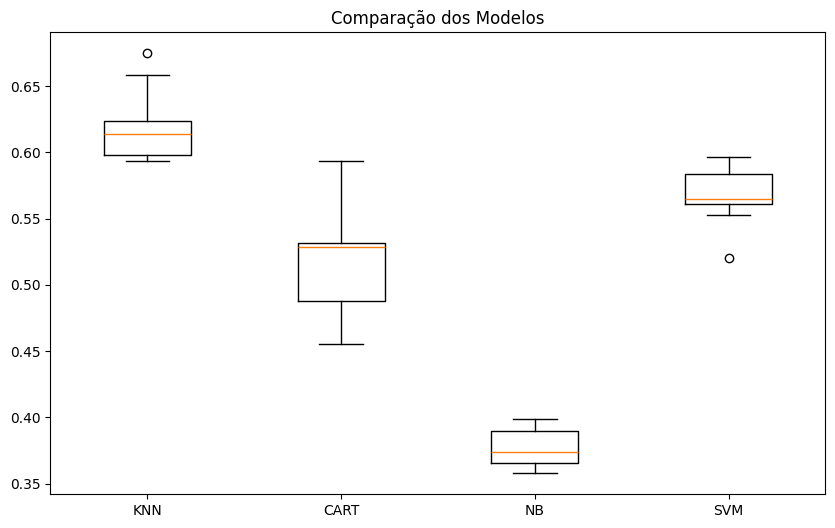

In [20]:
plt.figure(figsize=(10,6))
plt.boxplot(results)
plt.xticks(range(1, len(names)+1), names)
plt.title('Comparação dos Modelos')
plt.show()

## Otimização de Hiperparâmetros

Será utilizado GridSearch para encontrar os melhores parâmetros para o modelo SVM.

In [21]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('svm', SVC())
])

param_grid = {
    'tfidf__max_features': [500, 1000],
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf']
}

grid = GridSearchCV(pipeline, param_grid, cv=kfold, scoring=scoring)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
best_model = grid.best_estimator_

Best parameters: {'svm__C': 1, 'svm__kernel': 'linear', 'tfidf__max_features': 1000}


## Avaliação Final no Conjunto de Teste

In [22]:
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6818181818181818

Classification Report:
                  precision    recall  f1-score   support

        fantasy       0.71      0.86      0.77        70
        history       0.94      0.80      0.86        20
         horror       0.25      0.05      0.08        20
     psychology       0.78      0.70      0.74        20
        romance       0.46      0.27      0.34        22
        science       0.92      0.75      0.83        16
science_fiction       1.00      0.11      0.20         9
         sports       0.78      0.44      0.56        16
       thriller       0.61      0.84      0.71        96
         travel       0.80      0.63      0.71        19

       accuracy                           0.68       308
      macro avg       0.72      0.55      0.58       308
   weighted avg       0.68      0.68      0.65       308



## Treinamento Final com Todos os Dados

In [23]:
best_model.fit(X, y)

Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=1000)),
                ('svm', SVC(C=1, kernel='linear'))])

## Exportação do Modelo

In [26]:
joblib.dump(best_model, "./model/modelo_genero_livros.pkl")

['sample_data/modelo_genero_livros.pkl']

## Possíveis Melhorias

- Uso de técnicas de NLP mais avançadas (Word Embeddings, BERT)
- Balanceamento de classes
- Aumento da base de dados